Langkah 2 - Import Library

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [2]:
print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


Langkah 3 - Muatkan dan Semak Dataset MNIST

In [3]:
transform = transforms.ToTensor()

In [4]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.64MB/s]


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [6]:
print("Training data:", len(train_dataset))
print("Testing data:", len(test_dataset))

Training data: 60000
Testing data: 10000


In [7]:
image, label = test_dataset[0]

print("Image shape:", image.shape)
print("Actual label:", label)

Image shape: torch.Size([1, 28, 28])
Actual label: 7


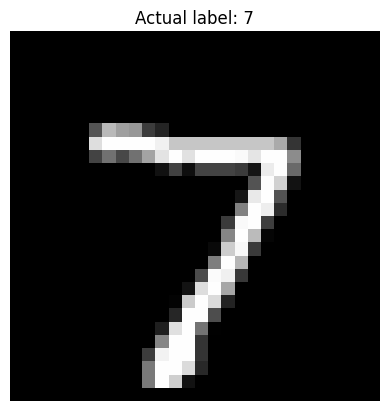

In [9]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Actual label: " + str(label))
plt.axis("off")
plt.show()

Langkah 4 - Bina Model ANN

In [10]:
class ANNModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [11]:
ann_model = ANNModel().to(device)

print(ann_model)

ANNModel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [12]:
criterion = nn.CrossEntropyLoss()

In [13]:
ann_optimizer = optim.Adam(
    ann_model.parameters(),
    lr=0.001
)

Langkah 5 - Latih dan Uji ANN

In [14]:
ann_model.train()

for epoch in range(2):

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        ann_optimizer.zero_grad()

        outputs = ann_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        ann_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        "Epoch {}/2 - Loss: {:.4f}".format(
            epoch + 1,
            average_loss
        )
    )

Epoch 1/2 - Loss: 0.3500
Epoch 2/2 - Loss: 0.1587


In [15]:
ann_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = ann_model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

ann_accuracy = 100 * correct / total

print(
    "ANN Testing Accuracy: {:.2f}%".format(
        ann_accuracy
    )
)

ANN Testing Accuracy: 96.00%


Langkah 6 - Bina Model CNN

In [16]:
class CNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                32 * 14 * 14,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                10
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [17]:
cnn_model = CNNModel().to(device)

print(cnn_model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [18]:
criterion = nn.CrossEntropyLoss()

cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001
)

In [19]:
sample_batch, sample_labels = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():

    pooled = cnn_model.features(sample_batch)

    sample_output = cnn_model(sample_batch)

print("Input batch:", list(sample_batch.shape))
print("Selepas pooling:", list(pooled.shape))
print("Output model:", list(sample_output.shape))

Input batch: [64, 1, 28, 28]
Selepas pooling: [64, 32, 14, 14]
Output model: [64, 10]


Langkah 7 - Latih dan Uji CNN

In [20]:
cnn_model.train()

for epoch in range(2):

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        cnn_optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        cnn_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        "Epoch {}/2 - Loss: {:.4f}".format(
            epoch + 1,
            average_loss
        )
    )

Epoch 1/2 - Loss: 0.2585
Epoch 2/2 - Loss: 0.0798


In [25]:
cnn_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

cnn_accuracy = 100 * correct / total

print(
    "CNN Testing Accuracy: {:.2f}%".format(
        cnn_accuracy
    )
)

CNN Testing Accuracy: 98.20%


Langkah 8 - Uji Pengecaman 5 imej digit

Imej 1:
Actual: 7
ANN Prediction: 7 [BETUL]
CNN Prediction: 7 [BETUL]

Imej 2:
Actual: 2
ANN Prediction: 2 [BETUL]
CNN Prediction: 2 [BETUL]

Imej 3:
Actual: 1
ANN Prediction: 1 [BETUL]
CNN Prediction: 1 [BETUL]

Imej 4:
Actual: 0
ANN Prediction: 0 [BETUL]
CNN Prediction: 0 [BETUL]

Imej 5:
Actual: 4
ANN Prediction: 4 [BETUL]
CNN Prediction: 4 [BETUL]



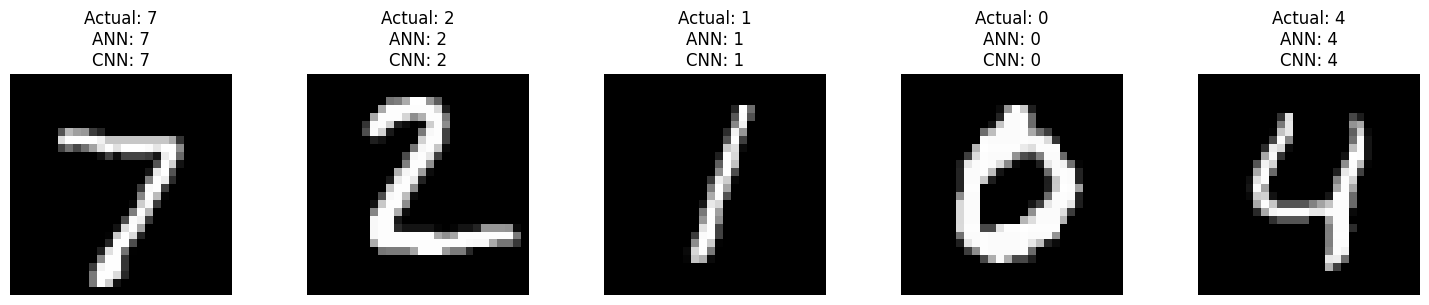

ANN betul: 5 / 5
CNN betul: 5 / 5


In [22]:
five_images = []
five_labels = []

for i in range(5):

    image, label = test_dataset[i]

    five_images.append(image)
    five_labels.append(label)


ann_correct_5 = 0
cnn_correct_5 = 0


fig, axes = plt.subplots(
    1,
    5,
    figsize=(15, 3)
)


for i in range(5):

    image = five_images[i]
    actual = five_labels[i]

    input_image = image.unsqueeze(0).to(device)


    with torch.no_grad():

        ann_output = ann_model(input_image)

        cnn_output = cnn_model(input_image)

        ann_prediction = torch.argmax(
            ann_output,
            dim=1
        ).item()

        cnn_prediction = torch.argmax(
            cnn_output,
            dim=1
        ).item()


    if ann_prediction == actual:

        ann_status = "BETUL"

        ann_correct_5 += 1

    else:

        ann_status = "SALAH"


    if cnn_prediction == actual:

        cnn_status = "BETUL"

        cnn_correct_5 += 1

    else:

        cnn_status = "SALAH"


    print("Imej {}:".format(i + 1))

    print(
        "Actual:",
        actual
    )

    print(
        "ANN Prediction:",
        ann_prediction,
        "[{}]".format(ann_status)
    )

    print(
        "CNN Prediction:",
        cnn_prediction,
        "[{}]".format(cnn_status)
    )

    print()


    axes[i].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[i].set_title(
        "Actual: {}\nANN: {}\nCNN: {}".format(
            actual,
            ann_prediction,
            cnn_prediction
        )
    )

    axes[i].axis("off")


plt.tight_layout()

plt.show()


print(
    "ANN betul:",
    ann_correct_5,
    "/ 5"
)

print(
    "CNN betul:",
    cnn_correct_5,
    "/ 5"
)

Langkah 9 - Perbandingan ANN dan CNN

In [26]:
print("JADUAL KEPUTUSAN")

print("-" * 60)

print(
    "{:<10} {:<10} {:<20} {:<20}".format(
        "MODEL",
        "EPOCH",
        "TESTING ACCURACY",
        "RAMALAN BETUL / 5"
    )
)

print("-" * 60)

print(
    "{:<10} {:<10} {:<20.2f} {:<20}".format(
        "ANN",
        2,
        ann_accuracy,
        ann_correct_5
    )
)

print(
    "{:<10} {:<10} {:<20.2f} {:<20}".format(
        "CNN",
        2,
        cnn_accuracy,
        cnn_correct_5
    )
)

print("-" * 60)

JADUAL KEPUTUSAN
------------------------------------------------------------
MODEL      EPOCH      TESTING ACCURACY     RAMALAN BETUL / 5   
------------------------------------------------------------
ANN        2          96.00                5                   
CNN        2          98.20                5                   
------------------------------------------------------------


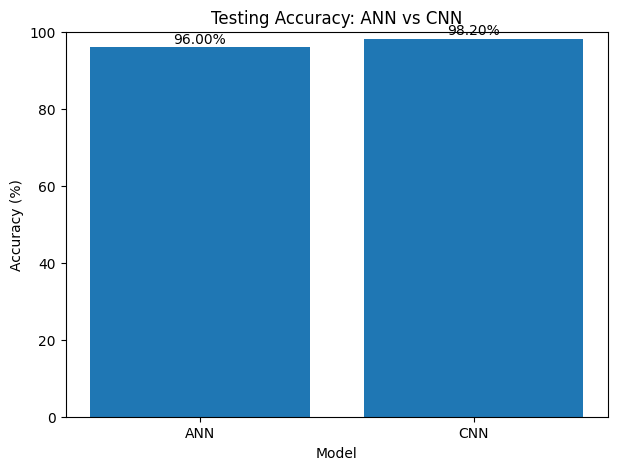

In [27]:
models = [
    "ANN",
    "CNN"
]

accuracies = [
    ann_accuracy,
    cnn_accuracy
]


plt.figure(figsize=(7, 5))

bars = plt.bar(
    models,
    accuracies
)


plt.title(
    "Testing Accuracy: ANN vs CNN"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(
    0,
    100
)


for bar, value in zip(
    bars,
    accuracies
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        "{:.2f}%".format(value),
        ha="center"
    )


plt.show()

In [28]:
if cnn_accuracy > ann_accuracy:

    higher_accuracy = "CNN"

elif ann_accuracy > cnn_accuracy:

    higher_accuracy = "ANN"

else:

    higher_accuracy = "ANN dan CNN mempunyai accuracy yang sama"


if cnn_correct_5 > ann_correct_5:

    more_correct = "CNN"

elif ann_correct_5 > cnn_correct_5:

    more_correct = "ANN"

else:

    more_correct = "ANN dan CNN mempunyai bilangan ramalan betul yang sama"


print(
    "Testing accuracy lebih tinggi:",
    higher_accuracy
)

print(
    "Lebih banyak ramalan betul daripada 5 imej:",
    more_correct
)

Testing accuracy lebih tinggi: CNN
Lebih banyak ramalan betul daripada 5 imej: ANN dan CNN mempunyai bilangan ramalan betul yang sama


Langkah 10 - Rekod AI + Git

## Langkah 10 — Rekod AI Code Assistant

**Nama AI Code Assistant:** ChatGPT

**Prompt yang digunakan:**

"Based on the DKA3223 PB Amali 1 requirements, help me structure a simple PyTorch notebook for MNIST using an ANN and a CNN, including training for 2 epochs, testing accuracy, five-image prediction, comparison and a bar graph."

**Ringkasan cadangan:**

AI mencadangkan struktur notebook menggunakan PyTorch dan dataset MNIST. Cadangan merangkumi DataLoader dengan batch size 64, model ANN menggunakan Flatten, Linear dan ReLU, model CNN menggunakan Conv2d, ReLU dan MaxPool2d, latihan selama dua epoch, pengiraan testing accuracy, lima ramalan imej serta graf perbandingan.

**Tindakan selepas menyemak cadangan:**

Kod disemak dan disusun mengikut keperluan tugasan. Output sebenar seperti training loss, testing accuracy dan keputusan lima imej diperoleh selepas notebook dijalankan. Cadangan AI yang tidak diperlukan tidak digunakan.
